In [231]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time
import pandas as pd

# Setup Chrome options
options = Options()
options.add_argument("--start-maximized")
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-infobars")
options.add_argument('--disable-extensions')

# ChromeDriver path
service = Service('C:\\Users\\user\\Downloads\\chromedriver-win64 (3)\\chromedriver-win64\\chromedriver.exe')
driver = webdriver.Chrome(service=service, options=options)

# Categories to scrape
categories = [
   "house accessories",
    "books",
    "beauty products",
    "office supplies"
]

# Loop through each category
for category in categories:
    all_products = []

    for page in range(1, 27):  # Scrape first 25 pages
        print(f"Scraping {category} - Page {page}")
        url = f"https://www.flipkart.com/search?q={category}&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={page}"
        driver.get(url)
        time.sleep(4)

        # Close login popup if present
        try:
            close_button = driver.find_element(By.XPATH, '//button[contains(text(),"✕")]')
            close_button.click()
        except:
            pass

        # Parse the page
        soup = BeautifulSoup(driver.page_source, 'html.parser')
        products = soup.find_all('a', class_='wjcEIp')

        # Extract details
        for product in products:
            name = product.get('title') or 'No name'
            price_tag = product.find_next('div', class_='Nx9bqj')
            rating_tag = product.find_next('div', class_='XQDdHH')
            review_tag = product.find_next('span', class_='Wphh3N')

            price = price_tag.text.strip() if price_tag else 'No price'
            rating = rating_tag.text.strip() if rating_tag else 'No rating'
            reviews = review_tag.text.strip() if review_tag else 'No reviews'

            all_products.append([name, price, rating, reviews, category])

    # Convert to DataFrame and save
    df = pd.DataFrame(all_products, columns=['Product Name', 'Price', 'Rating', 'Number of Reviews', 'Category'])
    df.to_csv(f'flipkart_{category.lower()}_data.csv', index=False)
    print(f"✅ Saved: flipkart_{category.lower()}_25pages.csv with {len(df)} records")

driver.quit()


Scraping House Accessories - Page 1
Scraping House Accessories - Page 2
Scraping House Accessories - Page 3
Scraping House Accessories - Page 4
Scraping House Accessories - Page 5
Scraping House Accessories - Page 6
Scraping House Accessories - Page 7
Scraping House Accessories - Page 8
Scraping House Accessories - Page 9
Scraping House Accessories - Page 10
Scraping House Accessories - Page 11
Scraping House Accessories - Page 12
Scraping House Accessories - Page 13
Scraping House Accessories - Page 14
Scraping House Accessories - Page 15
Scraping House Accessories - Page 16
Scraping House Accessories - Page 17
Scraping House Accessories - Page 18
Scraping House Accessories - Page 19
Scraping House Accessories - Page 20
Scraping House Accessories - Page 21
Scraping House Accessories - Page 22
Scraping House Accessories - Page 23
Scraping House Accessories - Page 24
Scraping House Accessories - Page 25
Scraping House Accessories - Page 26
✅ Saved: flipkart_house accessories_25pages.csv

In [2]:
import pandas as pd
import glob
import os
import warnings
warnings.filterwarnings('ignore')


csv_files = [
    "flipkart_house accessories_data.csv",
    "flipkart_books_data.csv",
    "flipkart_beauty products_data.csv",
    "flipkart_office supplies_data.csv"
]


# Combined DataFrame
combined_df = pd.DataFrame()

for file in csv_files:
    df = pd.read_csv(file)
    
    # Extract category from filename
    category = os.path.basename(file).split('_')[1]  # Gets "electronics", "accessories", etc.
    df['Category'] = category.capitalize()  # Add Category column
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Save combined dataset
combined_df.to_csv("flipkart_Product_sales_data.csv", index=False)
print("✅ Combined dataset saved as 'flipkart_Product_sales_data.csv'")# List of files to merge



✅ Combined dataset saved as 'flipkart_Product_sales_data.csv'


In [114]:
df =pd.read_csv(r"flipkart_Product_sales_data.csv")
df

,Product Name,Price,Rating,Number of Reviews,Category
0,Baby Poster - 13x19 Inch - Cute Wall Decor for...,₹125,3.7,"(6,012)",House accessories
1,Aarul Fashion Home Decor Pot Stand Set of 4 Pi...,₹75,3.7,"(6,012)",House accessories
2,CAPIO ART GEOMETRIC multipurpose design Wood K...,₹99,4.0,"(1,35,024)",House accessories
3,Khatu Crafts Om Swastik Key holder for home / ...,₹88,4.0,"(55,320)",House accessories
4,Baby Wall Poster Bundle - Adorable Designs for...,₹235,4.0,"(2,206)",House accessories
...,...,...,...,...,...
3995,Krink KNP_PEN_B252 Premium ball pen | Lightwei...,₹205,4.0,(10),Office supplies
3996,MAKENSTYLECOLLECTION Handmade Diary with Love ...,₹232,4.0,(10),Office supplies
3997,MAKENSTYLECOLLECTION Handmade Diary with Love ...,₹241,4.4,(103),Office supplies
3998,Buyer Choice Waterproof Adhesive Tape for Surf...,₹165,4.0,(3),Office supplies


In [115]:
df.head()

,Product Name,Price,Rating,Number of Reviews,Category
0,Baby Poster - 13x19 Inch - Cute Wall Decor for...,₹125,3.7,"(6,012)",House accessories
1,Aarul Fashion Home Decor Pot Stand Set of 4 Pi...,₹75,3.7,"(6,012)",House accessories
2,CAPIO ART GEOMETRIC multipurpose design Wood K...,₹99,4.0,"(1,35,024)",House accessories
3,Khatu Crafts Om Swastik Key holder for home / ...,₹88,4.0,"(55,320)",House accessories
4,Baby Wall Poster Bundle - Adorable Designs for...,₹235,4.0,"(2,206)",House accessories


In [116]:
df.tail()

,Product Name,Price,Rating,Number of Reviews,Category
3995,Krink KNP_PEN_B252 Premium ball pen | Lightwei...,₹205,4.0,(10),Office supplies
3996,MAKENSTYLECOLLECTION Handmade Diary with Love ...,₹232,4.0,(10),Office supplies
3997,MAKENSTYLECOLLECTION Handmade Diary with Love ...,₹241,4.4,(103),Office supplies
3998,Buyer Choice Waterproof Adhesive Tape for Surf...,₹165,4.0,(3),Office supplies
3999,Metrite INDIA Single Sided Medium Leak Proof R...,₹236,3.7,No reviews,Office supplies


In [117]:
import numpy as np

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       4000 non-null   object 
 1   Price              4000 non-null   object 
 2   Rating             4000 non-null   float64
 3   Number of Reviews  4000 non-null   object 
 4   Category           4000 non-null   object 
dtypes: float64(1), object(4)
memory usage: 156.4+ KB


In [119]:
df.replace("No name", np.nan, inplace=True)
df.replace("No price", np.nan, inplace=True)
df.replace("No rating", np.nan, inplace=True)
df.replace("No reviews", np.nan, inplace=True)

In [120]:
df.isnull().sum()

Product Name          0
Price                 0
Rating                0
Number of Reviews    32
Category              0
dtype: int64

In [121]:
df.dropna(inplace = True)

In [122]:
df.isnull().sum()

Product Name         0
Price                0
Rating               0
Number of Reviews    0
Category             0
dtype: int64

In [123]:
df.duplicated().sum()

375

In [124]:
df.drop_duplicates(inplace =True)

In [125]:
df.duplicated().sum()

0

In [126]:
# clean number of reviews (e.g (151) - 151)

df["Number of Reviews"] = df["Number of Reviews"].str.replace('(',"",regex = False)
df["Number of Reviews"] = df["Number of Reviews"].str.replace(')',"",regex = False)
df["Number of Reviews"] = df["Number of Reviews"].str.replace(',',"",regex = False)


In [127]:
df.head()

,Product Name,Price,Rating,Number of Reviews,Category
0,Baby Poster - 13x19 Inch - Cute Wall Decor for...,₹125,3.7,6012,House accessories
1,Aarul Fashion Home Decor Pot Stand Set of 4 Pi...,₹75,3.7,6012,House accessories
2,CAPIO ART GEOMETRIC multipurpose design Wood K...,₹99,4.0,135024,House accessories
3,Khatu Crafts Om Swastik Key holder for home / ...,₹88,4.0,55320,House accessories
4,Baby Wall Poster Bundle - Adorable Designs for...,₹235,4.0,2206,House accessories


In [128]:
df["Number of Reviews"] = pd.to_numeric(df["Number of Reviews"], errors = 'coerce')

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3593 entries, 0 to 3998
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       3593 non-null   object 
 1   Price              3593 non-null   object 
 2   Rating             3593 non-null   float64
 3   Number of Reviews  3593 non-null   int64  
 4   Category           3593 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 168.4+ KB


In [130]:
df['Price'] = df['Price'].str.replace('₹', '', regex=False)
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce') 

In [131]:
df['Number of Reviews'] = df['Number of Reviews'].fillna(0)
df.dropna(subset=['Product Name', 'Price', 'Rating'], inplace=True)

In [132]:
df['Category'] = df['Category'].str.title().str.strip()

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3593 entries, 0 to 3998
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       3593 non-null   object 
 1   Price              3593 non-null   int64  
 2   Rating             3593 non-null   float64
 3   Number of Reviews  3593 non-null   int64  
 4   Category           3593 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 168.4+ KB
None


,Product Name,Price,Rating,Number of Reviews,Category
0,Baby Poster - 13x19 Inch - Cute Wall Decor for...,125,3.7,6012,House Accessories
1,Aarul Fashion Home Decor Pot Stand Set of 4 Pi...,75,3.7,6012,House Accessories
2,CAPIO ART GEOMETRIC multipurpose design Wood K...,99,4.0,135024,House Accessories
3,Khatu Crafts Om Swastik Key holder for home / ...,88,4.0,55320,House Accessories
4,Baby Wall Poster Bundle - Adorable Designs for...,235,4.0,2206,House Accessories


In [133]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply to multiple columns
df_cleaned = remove_outliers_iqr(df, 'Price')
df_cleaned = remove_outliers_iqr(df_cleaned, 'Rating')
df_cleaned = remove_outliers_iqr(df_cleaned, 'Number of Reviews')
df = df_cleaned.copy()

In [134]:
df['Product Name'] = df['Product Name'].astype(str).str.title()
df['Category'] = df['Category'].astype(str).str.capitalize()

In [135]:
df.describe()

,Price,Rating,Number of Reviews
count,2847.000000,2847.000000,2847.000000
mean,251.484018,4.121637,452.520197
std,138.033344,0.298878,625.971519
min,13.000000,3.300000,2.000000
25%,149.000000,3.900000,33.000000
50%,219.000000,4.100000,170.000000
75%,328.000000,4.300000,584.000000
max,668.000000,4.800000,2762.000000


In [136]:
df['Category'].value_counts()

Category
Beauty products      735
Books                722
Office supplies      707
House accessories    683
Name: count, dtype: int64

In [137]:

# Ensure columns are clean (if not already)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Number of Reviews'] = pd.to_numeric(df['Number of Reviews'], errors='coerce')

# Group by Category to get insights
category_stats = df.groupby("Category").agg({
    'Rating': 'mean',
    'Price': 'mean',
    'Number of Reviews': 'sum'
}).round(2).reset_index()

# Rename columns for clarity
category_stats.columns = ['Category', 'Average Rating', 'Average Price', 'Total Reviews']

# Display the result
print(category_stats)


            Category  Average Rating  Average Price  Total Reviews
0    Beauty products            4.11         277.61         157573
1              Books            4.28         263.80         461030
2  House accessories            3.99         209.44         344215
3    Office supplies            4.10         252.36         325507


In [138]:
df.sort_values(by='Price', ascending=False).head(10)

,Product Name,Price,Rating,Number of Reviews,Category
3778,Aroowin Handcrafted Gift Regular Diary Single ...,668,4.4,1163,Office supplies
1065,Ncert Science Book Set Pcb 1.Physics Textbook ...,664,4.2,1894,Books
3607,"Zweelay Marble Shade Diary With Lock, Number P...",664,4.1,12,Office supplies
3369,Greeshma Monthly Planner 15 Months Of Appointm...,664,4.5,8,Office supplies
2461,Misti Herbal Remedies Ayurvedic Gold Malam,662,4.2,13,Beauty products
3602,"Vikrida Combo Set Of 3D Pen, Lcd Display With ...",661,3.7,407,Office supplies
3337,Krinus Leather Waterproof Refillable A5 Daily ...,661,3.7,429,Office supplies
3872,Everglow 200 Pg A4 Diary Running 200 Pages,660,4.0,6,Office supplies
3707,Antopy Regular Diary A5 Diary Password Locked ...,659,4.5,15,Office supplies
554,Kaykon Big Artificial Palm Tree Natural Lookin...,658,4.3,2356,House accessories


In [139]:
top_rated = df[df['Rating'] >= 4.5].sort_values(by='Rating', ascending=False)
top_rated[['Product Name', 'Rating', 'Category']].head(10)

,Product Name,Rating,Category
2815,"Arcanuy Hard Body Wax Beans For Face, Arms, Le...",4.8,Beauty products
2647,"Luzimaisa Best Hair Removal For Women, Easy-To...",4.8,Beauty products
2088,Chemist At Play Sunscreen - Spf 50 Pa++++ Hydr...,4.8,Beauty products
2225,Sunscoop Sunscreen - Spf 50+ Pa++++ Ceramide &...,4.8,Beauty products
2245,Glisna Fresh Mix Herbs Burst Ubtan Face Wash D...,4.8,Beauty products
2331,"Gemblue Biocare Fruit Gel For Face And Body, E...",4.8,Beauty products
946,Hirsha Key Holder Without Drill Decorative Sho...,4.8,House accessories
2644,Nn All Skin Type Body Hair Removal Spray Pack ...,4.8,Beauty products
2645,"Makeup Mania Non-Woven Body Wax Strips, Hair R...",4.8,Beauty products
2646,Pramukh Cucumber Face Wash (Pack Of 5) Face Wash,4.8,Beauty products


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2847 entries, 4 to 3998
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       2847 non-null   object 
 1   Price              2847 non-null   int64  
 2   Rating             2847 non-null   float64
 3   Number of Reviews  2847 non-null   int64  
 4   Category           2847 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 133.5+ KB


In [141]:
import seaborn as sns
import matplotlib.pyplot as plt


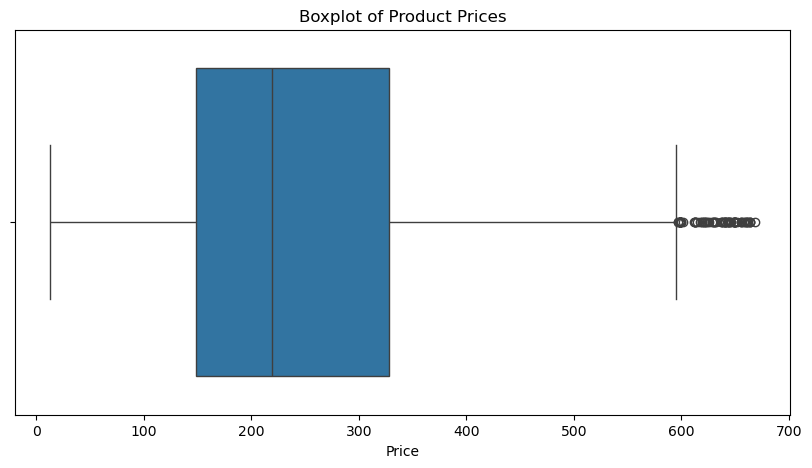

In [142]:

plt.figure(figsize=(10,5))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Product Prices")
plt.show()


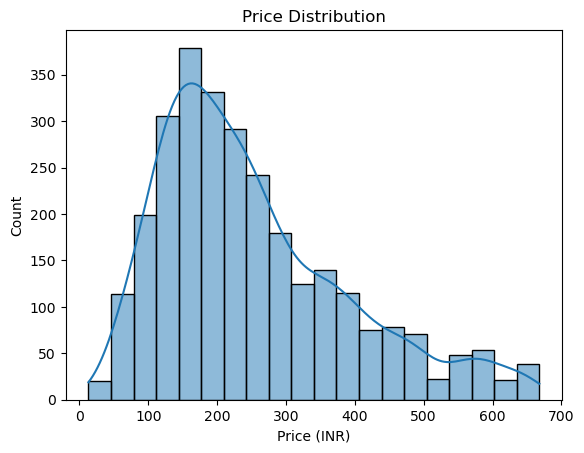

In [31]:
sns.histplot(df['Price'], kde=True, bins=20)
plt.title("Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.show()

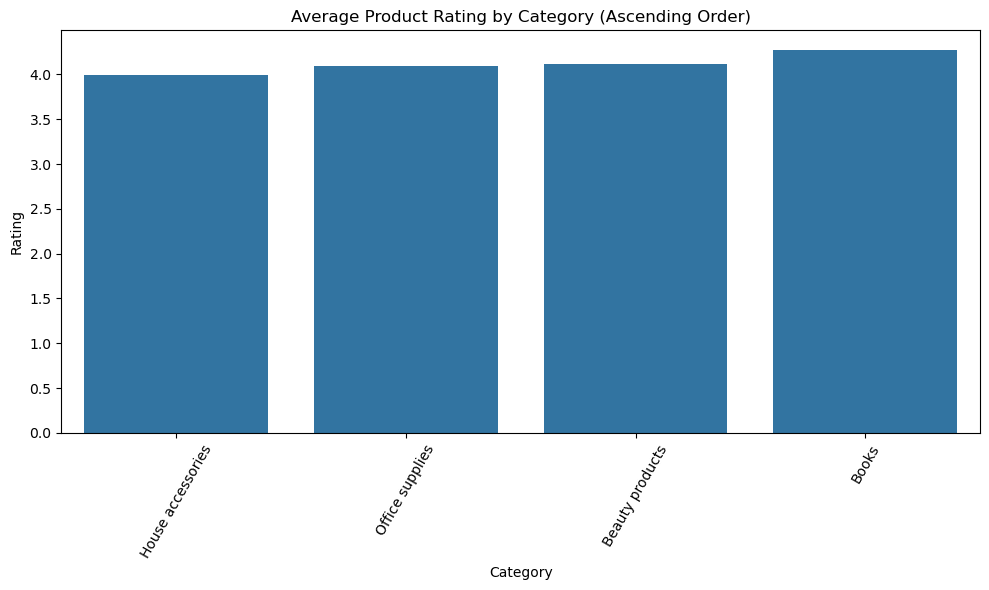

In [32]:
# Group by category and calculate mean rating, then sort
avg_ratings = df.groupby('Category')['Rating'].mean().sort_values(ascending=True).reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_ratings, x='Category', y='Rating')
plt.title("Average Product Rating by Category (Ascending Order)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

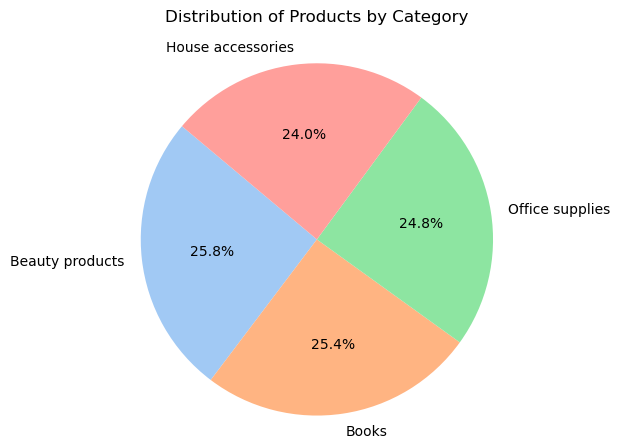

In [35]:
# Get category counts
category_counts = df['Category'].value_counts()

# Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Distribution of Products by Category\n")
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
plt.show()


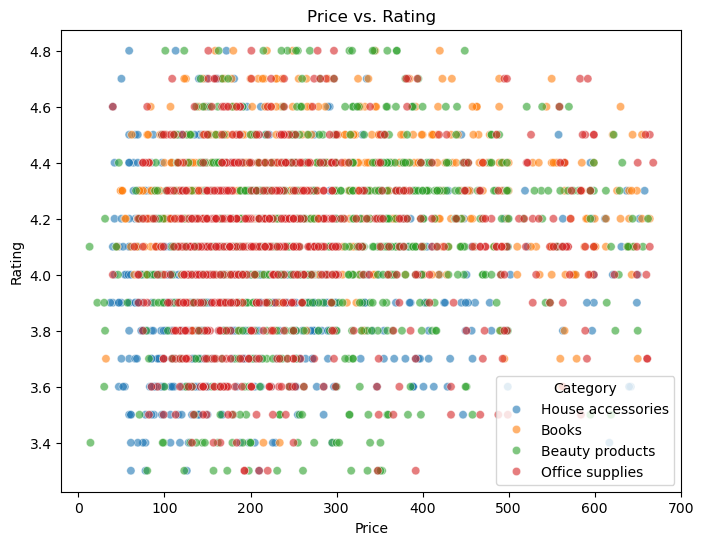

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Price', y='Rating', hue='Category', alpha=0.6)
plt.title("Price vs. Rating")
plt.show()


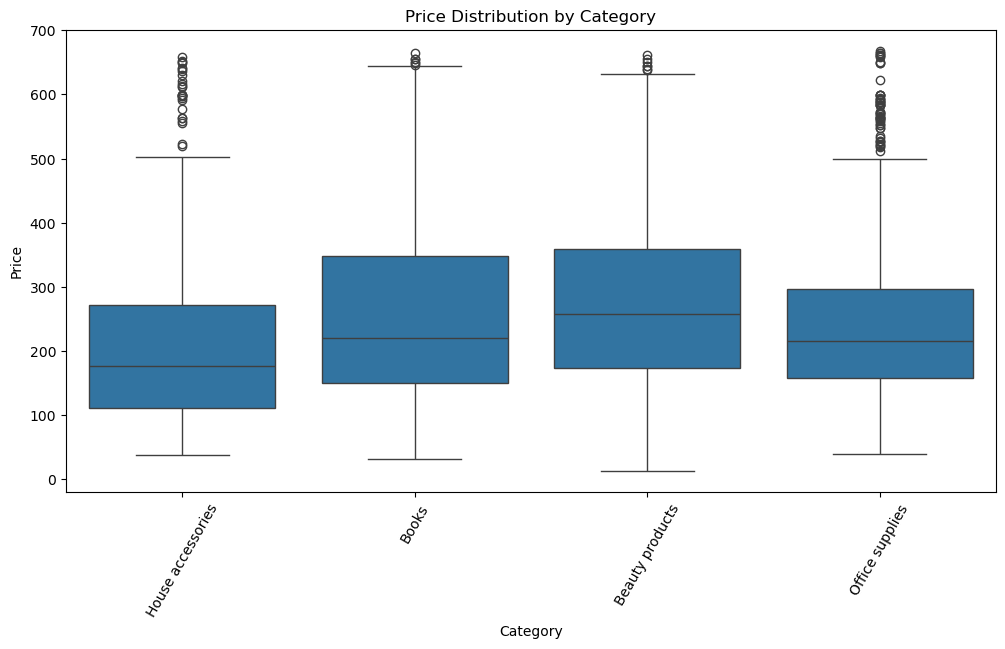

In [37]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Category', y='Price')
plt.title("Price Distribution by Category")
plt.xticks(rotation=60)
plt.show()


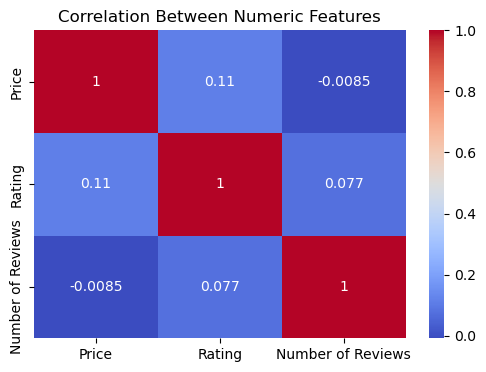

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Price', 'Rating', 'Number of Reviews']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()


In [39]:
most_reviewed = df.sort_values(by='Number of Reviews', ascending=False).head(10)
most_reviewed[['Product Name', 'Number of Reviews', 'Rating','Category']]


,Product Name,Number of Reviews,Rating,Category
1147,"Ncer Mathematics Class12 Volume1&2 Paperback, ...",2762,4.3,Books
1239,Neetu Singh English Class Notes | Latest Edition,2761,4.4,Books
2066,Foxtale Sunscreen - Spf 70 Pa++++ Dewy Sunscre...,2759,4.3,Beauty products
3069,Khiza Black Color Premium Professional Scissor...,2746,4.4,Office supplies
1036,Railway Reasoning|| 3300+ Pyqs With Solutions ...,2743,4.5,Books
3056,Stealodeal Retro Style Metal 70Mm 10X Magnifyi...,2738,4.1,Office supplies
1679,Electrician Theory For Competitive Exams Usefu...,2721,4.3,Books
1660,Bbd Special Edition Quantitative Aptitude For ...,2715,4.4,Books
1100,Aditya Ranjan Sir |Ssc Maths 6500+| Chapter-Wi...,2715,4.6,Books
3582,Nxntron Usb Finger Touch Cigarette Pocket Ligh...,2687,3.7,Office supplies


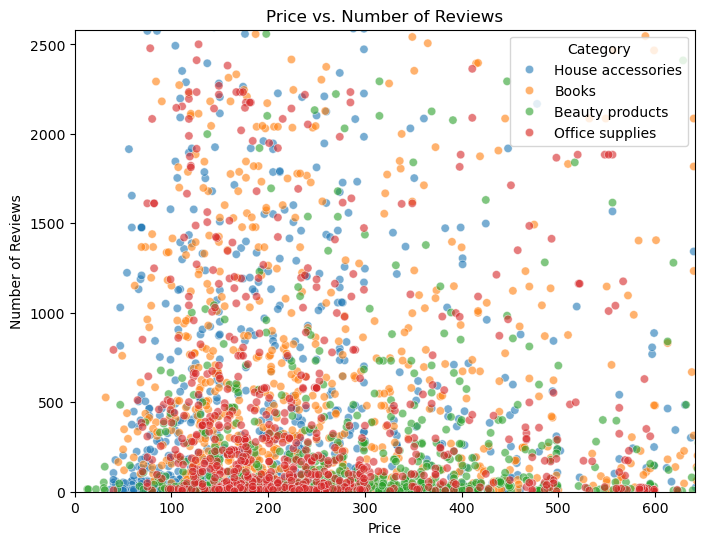

In [40]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Price', y='Number of Reviews', hue='Category', alpha=0.6)
plt.title("Price vs. Number of Reviews")
plt.xlim(0, df['Price'].quantile(0.99))
plt.ylim(0, df['Number of Reviews'].quantile(0.99))
plt.show()


In [41]:
df.to_csv(f'flipkart_Updated_data.csv', index=True)

In [42]:
df1 = pd.read_csv(r'flipkart_Updated_data.csv')
df1 = df1.drop(columns=['Unnamed: 0'], errors='ignore')
df1

,Product Name,Price,Rating,Number of Reviews,Category
0,Baby Wall Poster Bundle - Adorable Designs For...,235,4.0,2206,House accessories
1,Janaki Shop Macrame Rope Hanging Used As Wall ...,150,4.0,2206,House accessories
2,Separate Way Bong,174,3.9,2264,House accessories
3,Ps Steel 2 Spice Rack For Kitchen Stainless St...,193,3.8,1243,House accessories
4,Dreamydesign Tv Setup Box & Remote Stand Woode...,395,3.7,365,House accessories
...,...,...,...,...,...
2842,Searegal Fast Drying Oily Glue,145,3.6,78,Office supplies
2843,Krink Knp_Pen_B252 Premium Ball Pen | Lightwei...,205,4.0,10,Office supplies
2844,Makenstylecollection Handmade Diary With Love ...,232,4.0,10,Office supplies
2845,Makenstylecollection Handmade Diary With Love ...,241,4.4,103,Office supplies


In [43]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2847 entries, 0 to 2846
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       2847 non-null   object 
 1   Price              2847 non-null   int64  
 2   Rating             2847 non-null   float64
 3   Number of Reviews  2847 non-null   int64  
 4   Category           2847 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 111.3+ KB


In [44]:
pip install sqlalchemy sqlite


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sqlite (from versions: none)
ERROR: No matching distribution found for sqlite


In [45]:
import pandas as pd
from sqlalchemy import create_engine

# Create a database connection (SQLite for local storage)
engine = create_engine('sqlite:///flipkart_products_ecomerce.db', echo=True)

# Push the cleaned DataFrame to the database
df1.to_sql('products', con=engine, if_exists='replace', index=False)

print("✅ Data stored successfully in SQLite database.")


2025-04-09 07:30:09,502 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-04-09 07:30:09,515 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("products")
2025-04-09 07:30:09,516 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-04-09 07:30:09,518 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("products")
2025-04-09 07:30:09,519 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-04-09 07:30:09,519 INFO sqlalchemy.engine.Engine SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite~_%' ESCAPE '~' ORDER BY name
2025-04-09 07:30:09,519 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-04-09 07:30:09,525 INFO sqlalchemy.engine.Engine SELECT name FROM sqlite_master WHERE type='view' AND name NOT LIKE 'sqlite~_%' ESCAPE '~' ORDER BY name
2025-04-09 07:30:09,526 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-04-09 07:30:09,527 INFO sqlalchemy.engine.Engine PRAGMA main.table_xinfo("products")
2025-04-09 07:30:09,529 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-04-0

In [46]:
# Reading back from the database
engine = create_engine('sqlite:///flipkart_products_ecomerce.db', echo=True)
query = "SELECT * FROM products LIMIT 10;"
result = pd.read_sql(query, con=engine)
result


2025-04-09 07:30:22,180 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-04-09 07:30:22,181 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("SELECT * FROM products LIMIT 10;")
2025-04-09 07:30:22,182 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-04-09 07:30:22,184 INFO sqlalchemy.engine.Engine PRAGMA temp.table_info("SELECT * FROM products LIMIT 10;")
2025-04-09 07:30:22,186 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-04-09 07:30:22,186 INFO sqlalchemy.engine.Engine SELECT * FROM products LIMIT 10;
2025-04-09 07:30:22,186 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-04-09 07:30:22,193 INFO sqlalchemy.engine.Engine ROLLBACK


,Product Name,Price,Rating,Number of Reviews,Category
0,Baby Wall Poster Bundle - Adorable Designs For...,235,4.0,2206,House accessories
1,Janaki Shop Macrame Rope Hanging Used As Wall ...,150,4.0,2206,House accessories
2,Separate Way Bong,174,3.9,2264,House accessories
3,Ps Steel 2 Spice Rack For Kitchen Stainless St...,193,3.8,1243,House accessories
4,Dreamydesign Tv Setup Box & Remote Stand Woode...,395,3.7,365,House accessories
5,Candyvilla Digital Black Clock,250,3.8,1813,House accessories
6,Mehruna Dream Catchers Wall Hanging Home Decor...,150,4.3,740,House accessories
7,Purple Bookmarks – Set Of 16 – 2X6 Inches – Du...,205,4.2,1947,House accessories
8,Rss Enterprises Metal Wind Chimes With 4 Pipe ...,258,4.2,1947,House accessories
9,Askcrew Abstract Black Wallpaper,200,3.8,491,House accessories


In [49]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2847 entries, 0 to 2846
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Product Name       2847 non-null   object 
 1   Price              2847 non-null   int64  
 2   Rating             2847 non-null   float64
 3   Number of Reviews  2847 non-null   int64  
 4   Category           2847 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 111.3+ KB


## UnSupervised Training

In [80]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [81]:

# Drop 'Product Name' (text data) and encode 'Category' (optional)
df_encoded = pd.get_dummies(df1.drop(columns=['Product Name']), drop_first=True)

# Select numeric columns to scale
numeric_columns = ['Price', 'Rating', 'Number of Reviews']
df_numeric = df_encoded[numeric_columns]

# Normalize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

In [82]:
# Elbow Method to determine the optimal number of clusters
inertia = []
sil_scores = []

for n_clusters in range(2, 10):  
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_scaled)
    
    inertia.append(kmeans.inertia_)  # Sum of squared distances to the nearest cluster center
    
    # Silhouette Score (optional)
    sil_score = silhouette_score(df_scaled, kmeans.labels_)
    sil_scores.append(sil_score)

In [83]:
print("Inertia:")
inertia

Inertia:


[6508.248637888868,
 4539.7941865299845,
 3219.664707951762,
 2789.4375842863474,
 2538.1443282226237,
 2286.0639101643455,
 2073.6665441712526,
 1896.9994467276247]

In [84]:
print("Sil_scores")
sil_scores

Sil_scores


[0.28018830964422264,
 0.3271281069397135,
 0.3376010140310947,
 0.29892295612820213,
 0.29184953063699653,
 0.2890414770218814,
 0.29748659940216204,
 0.2886776456116286]

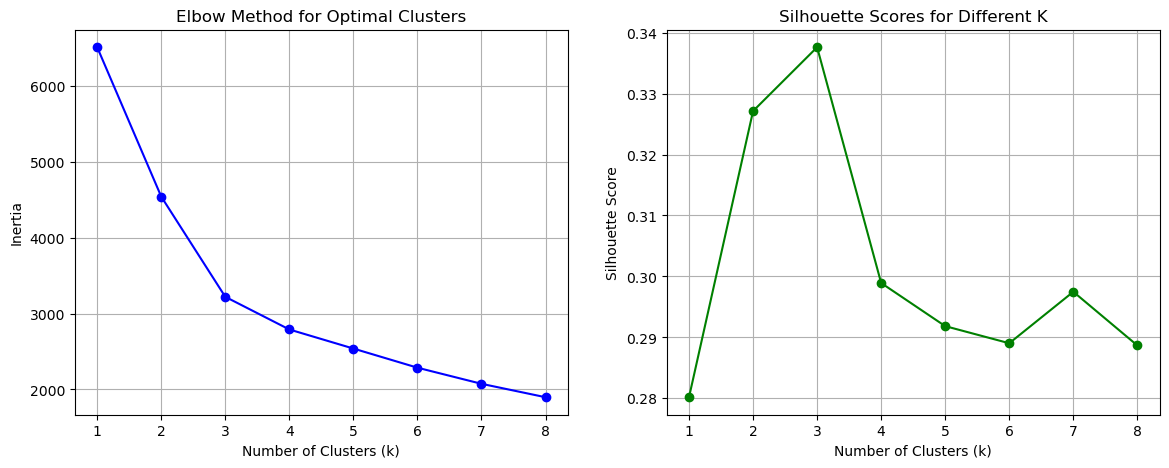

In [85]:
k_inertia = list(range(1, 9))
k_sil = list(range(1, 9))

# Plot side by side
plt.figure(figsize=(14, 5))

# Elbow plot
plt.subplot(1, 2, 1)
plt.plot(k_inertia, inertia, marker='o', color='blue')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(k_sil, sil_scores, marker='o', linestyle='-', color='green')
plt.title("Silhouette Scores for Different K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_sil)
plt.grid(True)


Inertia (Elbow Method)

Inertia is the sum of squared distances between data points and their assigned cluster centers. We look for the "elbow point", where the rate of decrease slows significantly — indicating diminishing returns for adding more clusters.

In this case:

Sharp drop from k=1 to k=3

After k=3, the decrease becomes more gradual

Elbow Point Candidate: k=3 (or k=4 as a backup option)

The highest silhouette score is at k=3, suggesting this is where the clustering structure is most distinct and meaningful.

The best number of clusters is k=3
because:

It shows a clear elbow point in the inertia curve.

It gives the highest silhouette score, indicating well-separated clusters.

Going beyond 3 clusters doesn't improve silhouette and adds unnecessary complexity.


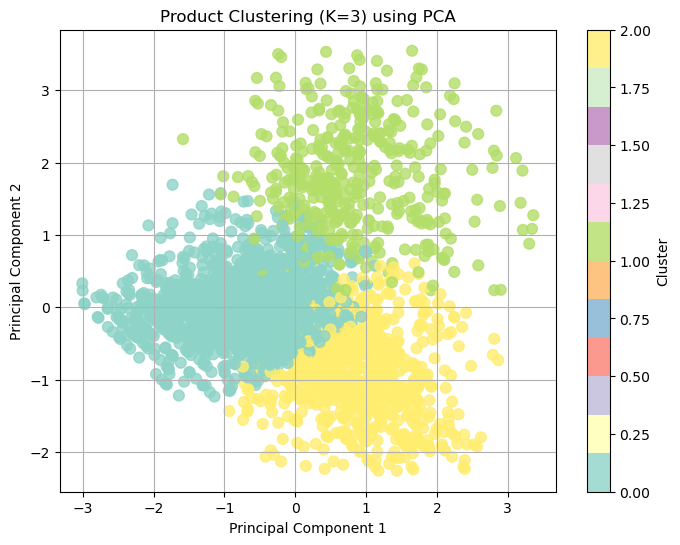

In [86]:
# Final K-Means with optimal number of clusters (example: k=4)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df1['Cluster'] = kmeans.fit_predict(df_scaled)

# Visualizing clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=df1['Cluster'], cmap='Set3', s=60, alpha=0.8)
plt.title(f'Product Clustering (K={optimal_k}) using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


In [87]:
cluster_summary = df1.groupby('Cluster')[['Price', 'Rating', 'Number of Reviews']].mean().round(2)
cluster_summary['Count'] = df1['Cluster'].value_counts()
print(cluster_summary)

          Price  Rating  Number of Reviews  Count
Cluster                                          
0        177.56    4.03             215.73   1619
1        233.10    4.18            1747.28    423
2        409.82    4.27             248.39    805


In [88]:
df1.to_csv("clustered_flipkart_products.csv", index=False)
print(" Clustered dataset saved!")


 Clustered dataset saved!


Cluster 1 (4168 products):
Budget-friendly and highly rated products with moderate review counts. This cluster represents the sweet spot for affordability and trust — great value for money.

Cluster 0 (1393 products):
Mid-range pricing with strong ratings and high review volume, indicating popular and dependable best-sellers.

Cluster 2 (928 products):
Higher price range with fewer reviews. These may be niche or newer products, possibly targeting a more selective audience.

In [89]:
cluster_labels = {
    0: 'Mid-Range Popular',
    1: 'Top-Rated Budget ',
    2: 'Premium Niche'
}

df1['Cluster_Label'] = df1['Cluster'].map(cluster_labels)
df1.head()

,Product Name,Price,Rating,Number of Reviews,Category,Cluster,Cluster_Label
0,Baby Wall Poster Bundle - Adorable Designs For...,235,4.0,2206,House accessories,1,Top-Rated Budget
1,Janaki Shop Macrame Rope Hanging Used As Wall ...,150,4.0,2206,House accessories,1,Top-Rated Budget
2,Separate Way Bong,174,3.9,2264,House accessories,1,Top-Rated Budget
3,Ps Steel 2 Spice Rack For Kitchen Stainless St...,193,3.8,1243,House accessories,1,Top-Rated Budget
4,Dreamydesign Tv Setup Box & Remote Stand Woode...,395,3.7,365,House accessories,2,Premium Niche


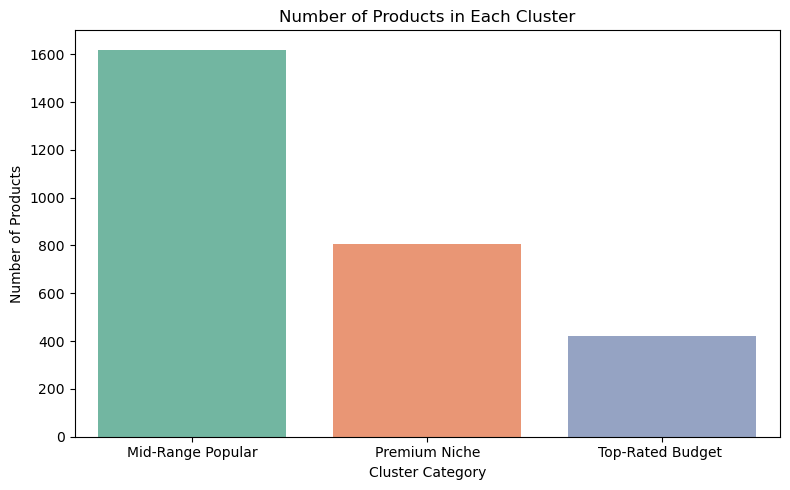

In [90]:
# Count of products in each cluster label
cluster_counts = df1['Cluster_Label'].value_counts().reset_index()
cluster_counts.columns = ['Cluster_Label', 'Count']

# Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_counts, x='Cluster_Label', y='Count', palette='Set2')

plt.title('Number of Products in Each Cluster')
plt.xlabel('Cluster Category')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

In [106]:
df1.head()

,Product Name,Price,Rating,Number of Reviews,Category,Cluster,Cluster_Label
0,Baby Wall Poster Bundle - Adorable Designs For...,235,4.0,2206,House accessories,1,Top-Rated Budget
1,Janaki Shop Macrame Rope Hanging Used As Wall ...,150,4.0,2206,House accessories,1,Top-Rated Budget
2,Separate Way Bong,174,3.9,2264,House accessories,1,Top-Rated Budget
3,Ps Steel 2 Spice Rack For Kitchen Stainless St...,193,3.8,1243,House accessories,1,Top-Rated Budget
4,Dreamydesign Tv Setup Box & Remote Stand Woode...,395,3.7,365,House accessories,2,Premium Niche


## Supervised Learning


In [107]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [108]:
# Drop non-feature columns
X = df1.drop(columns=['Product Name', 'Category', 'Cluster_Label'])

# One-hot encode categorical features (if any remain)
X = pd.get_dummies(X, drop_first=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df1['Category'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [109]:
df1['Category'].value_counts(normalize=True)


Category
Beauty products      0.258166
Books                0.253600
Office supplies      0.248332
House accessories    0.239902
Name: proportion, dtype: float64

In [110]:
# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(eval_metric='mlogloss')

}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append((name, acc, f1))

#  View model performance
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1 Score'])
print(results_df)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.364912  0.342326
1                  SVM  0.394737  0.360382
2                  KNN  0.396491  0.387657
3        Random Forest  0.454386  0.454345
4              XGBoost  0.452632  0.455299


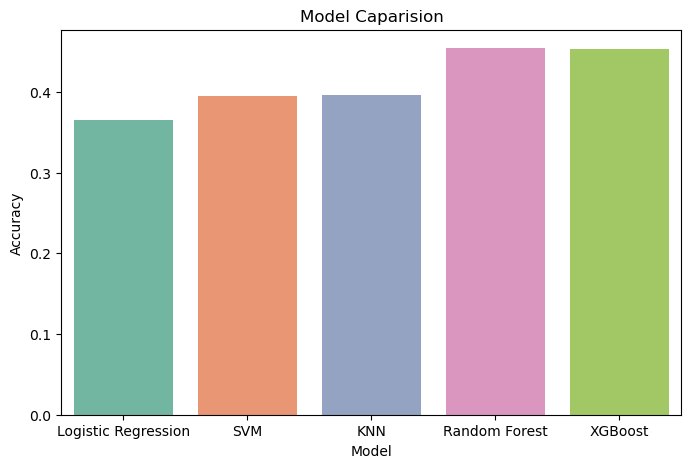

In [112]:
plt.figure(figsize=(8,5))
sns.barplot(data = results_df,x='Model',y = 'Accuracy',palette = 'Set2')
plt.title('Model Caparision')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()

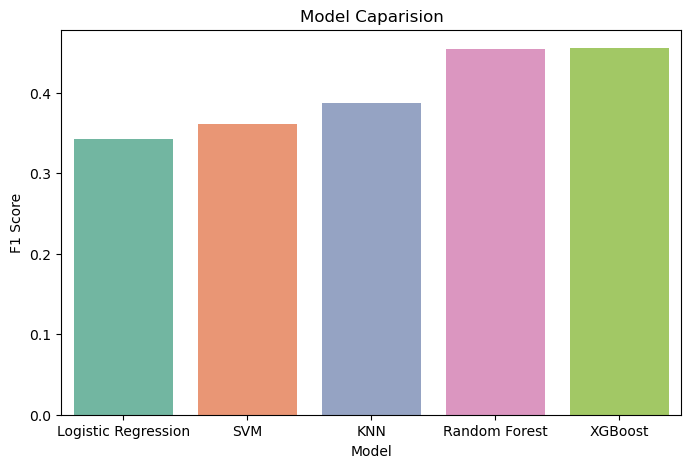

In [113]:
plt.figure(figsize=(8,5))
sns.barplot(data = results_df,x='Model',y = 'F1 Score',palette = 'Set2')
plt.title('Model Caparision')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.show()

In [477]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Set parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

# Initialize XGBoost classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, 
                           scoring='f1_weighted', cv=5, verbose=1, n_jobs=-1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters and performance
print("✅ Best Parameters:", grid_search.best_params_)
print("🔍 Best F1 Score from GridSearchCV:", grid_search.best_score_)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
✅ Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.6}
🔍 Best F1 Score from GridSearchCV: 0.49517701947625314


In [478]:
# Copy of the dataset
df = df1.copy()

# Encode the target label (Cluster_Label)
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Cluster_Label'])

# Drop unused columns (e.g., text labels)
X = df.drop(columns=['Product Name', 'Category', 'Cluster_Label', 'Target'])
X = pd.get_dummies(X, drop_first=True)  # In case any categorical features remain

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define target
y = df['Target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)
}

# Train and evaluate each model
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append((name, acc, f1))

# Output results
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1 Score'])
print("Model Performance (Predicting Clusters):")
print(results_df)


Model Performance (Predicting Clusters):
                 Model  Accuracy  F1 Score
0  Logistic Regression       1.0       1.0
1                  SVM       1.0       1.0
2                  KNN       1.0       1.0
3        Random Forest       1.0       1.0
4              XGBoost       1.0       1.0
